<a href="https://colab.research.google.com/github/emmex43/Machine-learning-fantasy/blob/main/Water_portability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Water Guardian — EDA & Model Training
**Notebook**: EDA, data cleaning, baseline models, hyperparameter tuning, final model export.

Assumes dataset at `../data/water_potability.csv` or `data/water_potability.csv`.

In [ ]:
# Cell 0 — imports & settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_recall_fscore_support, roc_curve, auc)
import joblib

# Optional: XGBoost
from xgboost import XGBClassifier

# Optional: handle imbalance
from imblearn.over_sampling import SMOTE

# plotting defaults
%matplotlib inline
sns.set(style='whitegrid')
pd.set_option('display.max_columns', 200)


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving water_potability.csv to water_potability (1).csv
User uploaded file "water_potability (1).csv" with length 525187 bytes


## Quick dataset info
- Target column: `Potability` (0 = Not potable / 1 = Potable)
- Features: pH, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic_carbon, Trihalomethanes, Turbidity
- Expect some missing values.

In [ ]:
# Cell 1 — load data
import os
import pandas as pd

DATA_PATH = 'water_potability.csv'  # adjust if needed
# Check if the file exists in the current directory, if not, try a 'data' subdirectory
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/water_potability.csv' # this path will only work if the file is in a 'data' subdirectory

# Check if the file exists in either location before trying to read
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Shape:", df.shape)
    display(df.head())
else:
    print(f"Error: The file '{DATA_PATH}' was not found.")
    print("Please upload the 'water_potability.csv' file or update the DATA_PATH variable.")

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
# Cell 2 — EDA: missing values, dtypes, summary stats
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Missing values per column:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


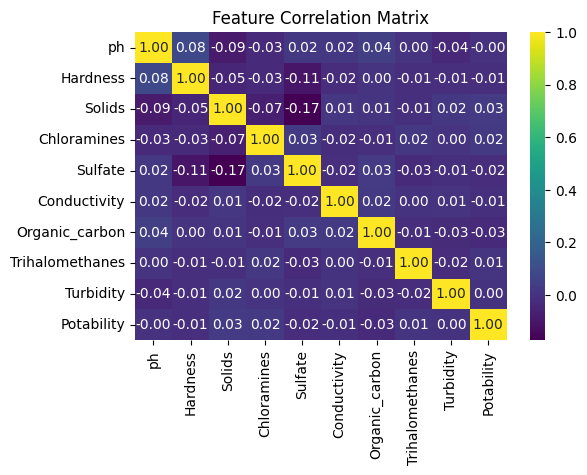

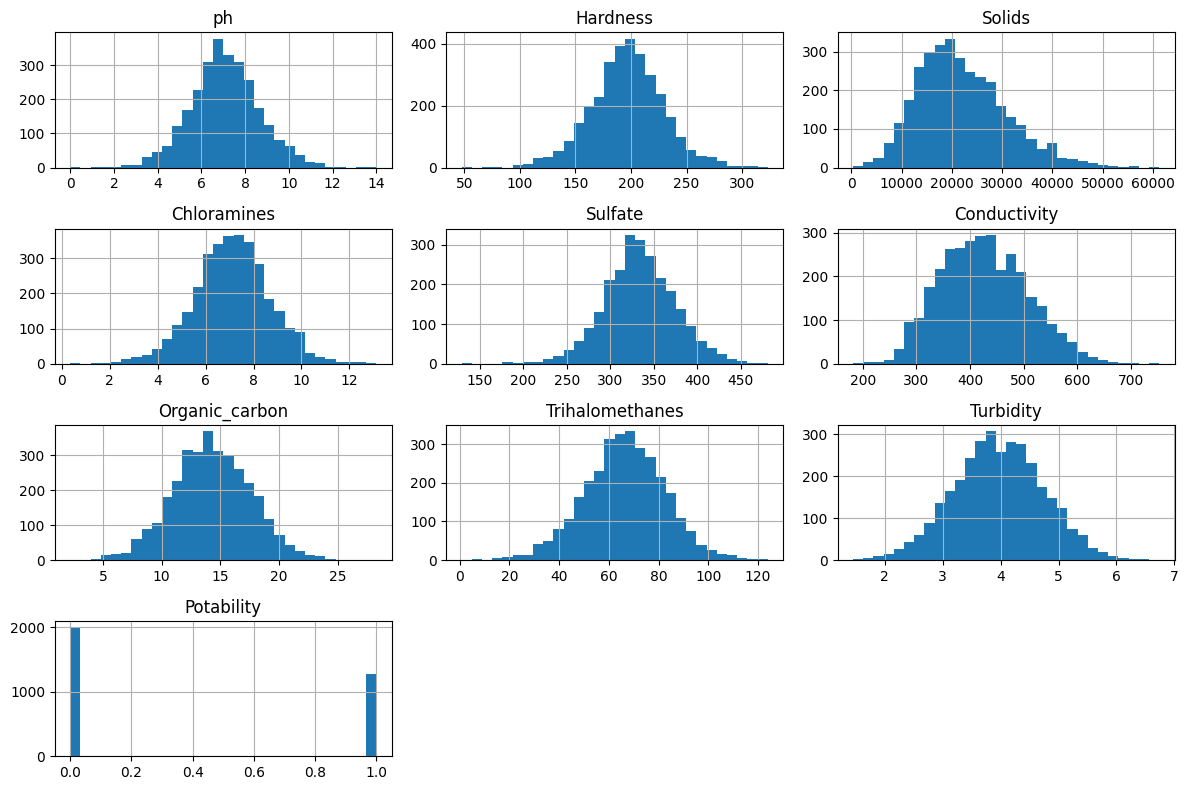

In [ ]:
# Cell 3 — Visualize distributions & correlations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()

# Histograms
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4 — missing value imputation & basic cleaning
df_clean = df.copy()
# Simple median imputation
df_clean.fillna(df_clean.median(), inplace=True)

# Quick outlier check (show rows with extreme turbidity or solids)
for col in ['Turbidity','Solids','ph','Conductivity']:
    print(col, "min/max:", df_clean[col].min(), df_clean[col].max())

df_clean.isna().sum()

Turbidity min/max: 1.45 6.739
Solids min/max: 320.942611274359 61227.19600771213
ph min/max: 0.0 13.999999999999998
Conductivity min/max: 181.483753985146 753.3426195583046


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
# Cell 5 — prepare X/y and check class balance
X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

print("Class distribution:\n", y.value_counts(normalize=False))
print("Class proportions:\n", y.value_counts(normalize=True))


Class distribution:
 Potability
0    1998
1    1278
Name: count, dtype: int64
Class proportions:
 Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


In [ ]:
# Cell 6 — train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (2620, 9) Test shape: (656, 9)


Classification report (RandomForest baseline):
              precision    recall  f1-score   support

           0       0.67      0.91      0.77       400
           1       0.68      0.29      0.41       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.59       656
weighted avg       0.67      0.67      0.63       656

ROC AUC: 0.6612841796875


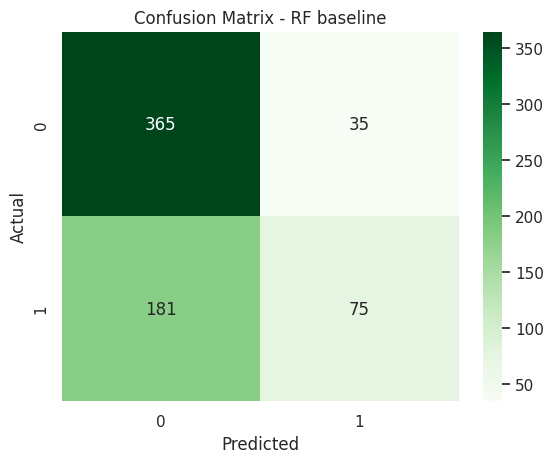

In [ ]:
# Cell 7 — attempt baseline RandomForest (class_weight balanced)
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print("Classification report (RandomForest baseline):")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - RF baseline')
plt.show()


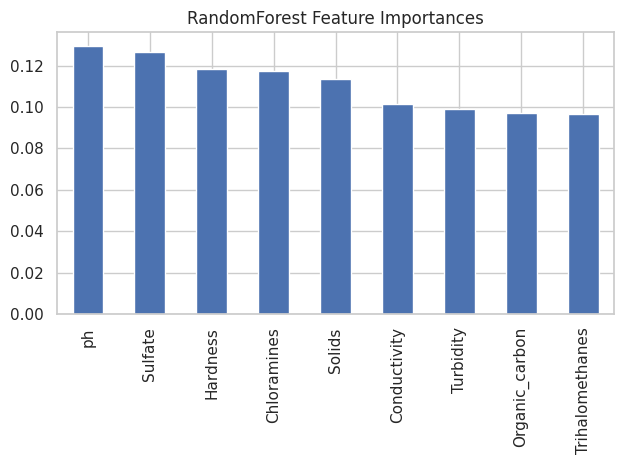

ph                 0.129659
Sulfate            0.126579
Hardness           0.118491
Chloramines        0.117531
Solids             0.113358
Conductivity       0.101510
Turbidity          0.099174
Organic_carbon     0.096901
Trihalomethanes    0.096796
dtype: float64


In [ ]:
# Cell 8 — feature importance (RF)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='RandomForest Feature Importances')
plt.tight_layout()
plt.show()
print(feat_imp)


In [ ]:
# Cell 9 — SMOTE on training set
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE, class distribution:", pd.Series(y_res).value_counts())


After SMOTE, class distribution: Potability
0    1598
1    1598
Name: count, dtype: int64


In [ ]:
# Cell 10 — simple XGBoost baseline (fast)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_res, y_res)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost baseline report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:47:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost baseline report:
              precision    recall  f1-score   support

           0       0.67      0.69      0.68       400
           1       0.49      0.47      0.48       256

    accuracy                           0.60       656
   macro avg       0.58      0.58      0.58       656
weighted avg       0.60      0.60      0.60       656

ROC AUC: 0.63671875


In [ ]:
# Cell 11 — GridSearchCV for XGBoost (small grid)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

grid = GridSearchCV(estimator=xgb_clf, param_grid=param_grid,
                    scoring='recall', cv=cv, n_jobs=-1, verbose=1)

grid.fit(X_res, y_res)  # trained on SMOTE-resampled training set
print("Best params:", grid.best_params_)
print("Best CV recall:", grid.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:48:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV recall: 0.6871247067010867


Classification report (best XGB):
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       400
           1       0.53      0.50      0.51       256

    accuracy                           0.63       656
   macro avg       0.61      0.61      0.61       656
weighted avg       0.63      0.63      0.63       656

ROC AUC: 0.654140625


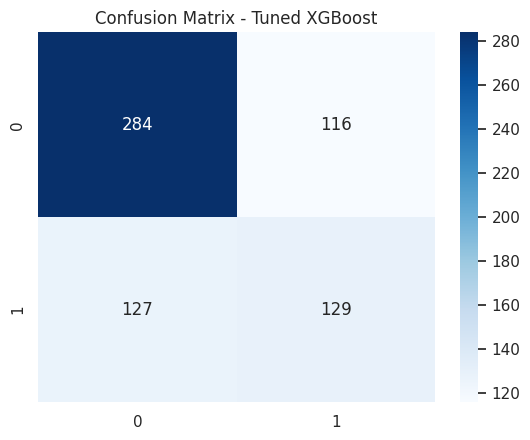

In [ ]:
# Cell 12 — evaluate best model on test set
best = grid.best_estimator_
y_pred_best = best.predict(X_test)
y_proba_best = best.predict_proba(X_test)[:,1]

print("Classification report (best XGB):")
print(classification_report(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()


In [ ]:
# Cell 13 — threshold tuning example (favor recall)
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)
# find threshold where recall >= 0.90 if possible
target_recall = 0.90
idx = np.where(recall >= target_recall)[0]
if len(idx)>0:
    chosen_idx = idx[-1]  # highest threshold that still has recall >= target_recall
    chosen_threshold = thresholds[chosen_idx] if chosen_idx < len(thresholds) else thresholds[-1]
    print("Chosen threshold for recall >= {:.2f}: {:.3f}".format(target_recall, chosen_threshold))
else:
    chosen_threshold = 0.5
    print("Could not reach target recall; default threshold 0.5 used.")

# Apply threshold
y_pred_thresh = (y_proba_best >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))


Chosen threshold for recall >= 0.90: 0.179
              precision    recall  f1-score   support

           0       0.77      0.20      0.32       400
           1       0.42      0.90      0.57       256

    accuracy                           0.48       656
   macro avg       0.59      0.55      0.45       656
weighted avg       0.63      0.48      0.42       656



In [ ]:
# Cell 14 — persist model and feature list
os.makedirs('../model', exist_ok=True)
MODEL_PATH = '../model/xgb_water_model.joblib'
joblib.dump(best, MODEL_PATH)
print("Saved model to", MODEL_PATH)

# Save feature order (so the Streamlit app knows how to map inputs)
feature_order = list(X.columns)
joblib.dump(feature_order, '../model/feature_order.joblib')
print("Saved feature list.")


Saved model to ../model/xgb_water_model.joblib
Saved feature list.


## Optional: SHAP explainability (if time and you can install `shap`)
- `pip install shap`
- Use SHAP to show per-sample explanations — great for demo and judges.


In [ ]:
pip install shap

Top features:
 ph                 0.133287
Sulfate            0.126784
Solids             0.124637
Chloramines        0.121779
Hardness           0.112962
Conductivity       0.098513
Turbidity          0.096555
Trihalomethanes    0.093234
Organic_carbon     0.092248
dtype: float32


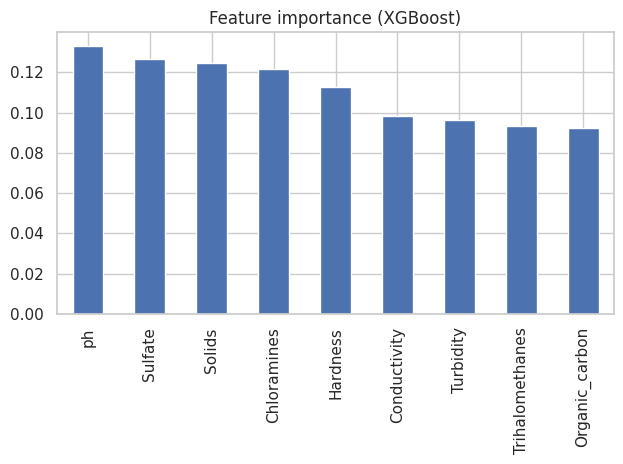

In [ ]:
# Cell 15 — feature importance for best XGBoost
fi = pd.Series(best.feature_importances_, index=feature_order).sort_values(ascending=False)
print("Top features:\n", fi.head(10))
fi.head(10).plot(kind='bar', title='Feature importance (XGBoost)')
plt.tight_layout()
plt.show()


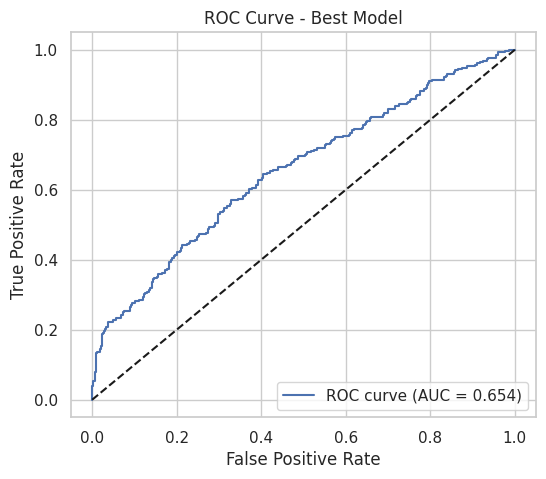

In [ ]:
# Cell 16 — quick ROC curve plot
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving water_potability.csv to water_potability.csv
User uploaded file "water_potability.csv" with length 525187 bytes


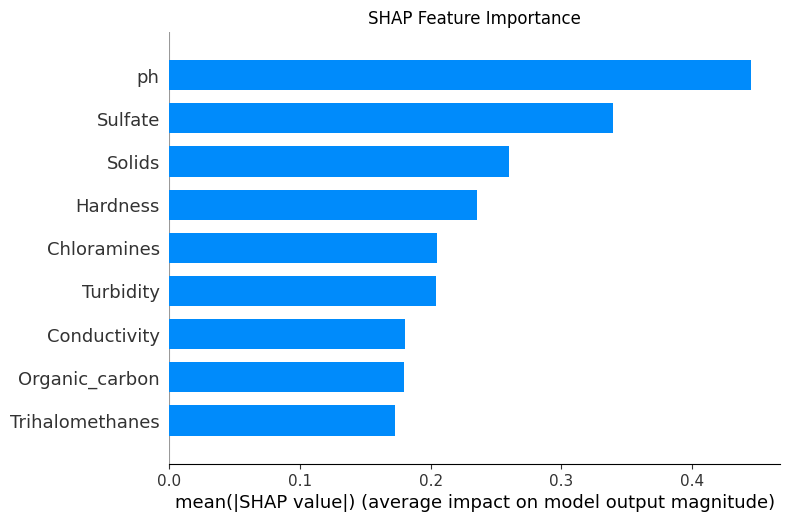

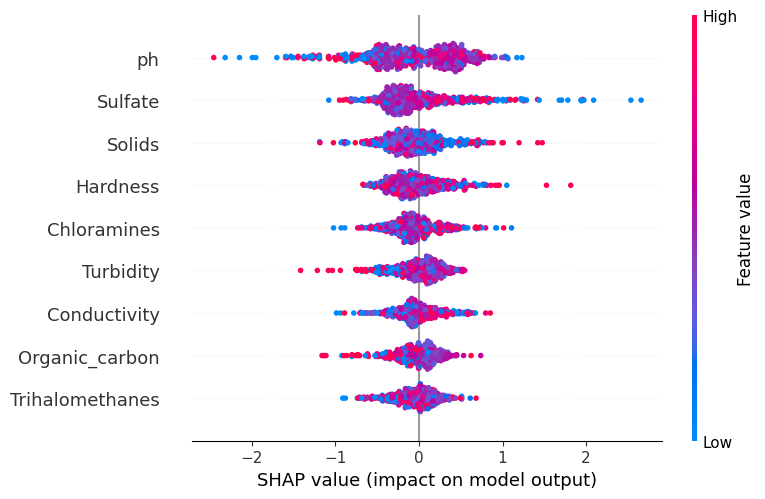

In [ ]:
import shap

# Create a SHAP Tree explainer for the best XGBoost model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Summarize the SHAP values to show the overall importance of features
# This is similar to feature importance but shows the magnitude and direction of impact
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.show()

# Plot the SHAP values for each instance
shap.summary_plot(shap_values, X_test)

The first plot above shows the global feature importance based on the mean absolute SHAP value. The second plot shows the SHAP values for each instance in the test set. Each dot represents an instance, and its position on the x-axis indicates the impact of that feature on the model's output (higher SHAP value means higher prediction of potability). The color indicates the feature value (red is high, blue is low).

We can also look at individual predictions to understand why the model made a specific prediction for a single water sample.

In [ ]:
# Explain the prediction for a single instance (e.g., the first instance in the test set)
instance_idx = 0
shap.initjs() # for interactive plots
shap.force_plot(explainer.expected_value, shap_values[instance_idx,:], X_test.iloc[instance_idx,:])

In the force plot above, features pushing the prediction higher (towards potable) are shown in red, and features pushing the prediction lower (towards not potable) are shown in blue. The size of each bar indicates the magnitude of the feature's impact.

Let me know if you'd like to explore the SHAP values for other instances or delve deeper into the interpretation of these plots!

In [ ]:
# Re-run cells to define best and explainer

# Cell 1 — load data
import os
import pandas as pd

DATA_PATH = 'water_potability.csv'  # adjust if needed
# Check if the file exists in the current directory, if not, try a 'data' subdirectory
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/water_potability.csv' # this path will only work if the file is in a 'data' subdirectory

# Check if the file exists in either location before trying to read
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Shape:", df.shape)
    # display(df.head()) # Removed display to keep output clean during re-run
else:
    print(f"Error: The file '{DATA_PATH}' was not found.")
    print("Please upload the 'water_potability.csv' file or update the DATA_PATH variable.")


# Cell 4 — missing value imputation & basic cleaning
df_clean = df.copy()
df_clean.fillna(df_clean.median(), inplace=True)

# Cell 5 — prepare X/y and check class balance
X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

# Cell 6 — train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Cell 9 — SMOTE on training set
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Cell 11 — GridSearchCV for XGBoost (small grid)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

grid = GridSearchCV(estimator=xgb_clf, param_grid=param_grid,
                    scoring='recall', cv=cv, n_jobs=-1, verbose=1)

grid.fit(X_res, y_res)
best = grid.best_estimator_

# Cell 14 — persist model and feature list (re-save)
import os
import joblib
os.makedirs('../model', exist_ok=True)
MODEL_PATH = '../model/xgb_water_model.joblib'
joblib.dump(best, MODEL_PATH)

feature_order = list(X.columns)
joblib.dump(feature_order, '../model/feature_order.joblib')

# Re-define explainer
import shap
explainer = shap.TreeExplainer(best)

print("Necessary variables re-defined.")

Shape: (3276, 10)
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:32:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Necessary variables re-defined.
